# Exploratory Data Analysis

Situation 2 ("Rating Wars"): before building a weighted rating, look at how the plain, unweighted rating behaves and how the helpfulness votes relate to it.

In [50]:
import matplotlib.pyplot as plt
import pandas as pd

from data_cleaning import DATA_PATH, load_and_clean

## Raw data check

Look at the CSV as it comes, before any cleaning, to find what needs fixing.

In [51]:
raw = pd.read_csv(DATA_PATH)
print(raw.shape)
print("Missing values:", raw.isna().sum().sum(), "| duplicate rows:", raw.duplicated().sum())
raw.dtypes

(2961, 7)
Missing values: 0 | duplicate rows: 0


Date of Review               str
User                         str
Usefulness Vote            int64
Total Votes                int64
User's Rating out of 10      str
Review Title                 str
Review                       str
dtype: object

User's Rating out of 10 was read as **text**, not a number. Its values show why:

In [52]:
raw["User's Rating out of 10"].str.strip().value_counts()

User's Rating out of 10
10                                            1618
9                                              533
8                                              242
Was this review helpful?  Sign in to vote.     200
7                                               88
1                                               87
6                                               51
4                                               37
5                                               36
2                                               35
3                                               34
Name: count, dtype: int64

In [53]:
print("Reviews with 0 total votes:", (raw["Total Votes"] == 0).sum())
print("Unique users:", raw["User"].nunique(), "for", len(raw), "reviews")

Reviews with 0 total votes: 446
Unique users: 2932 for 2961 reviews


**Findings**

- 2,961 reviews, no missing values, no duplicate rows.
- **200 ratings are not numbers** – the cell holds scraped page text, so these rows are dropped.
- **Date of Review** is text and has to be parsed as a date.
- Almost every user wrote one review, so quality is judged per review, not per user.

Cleaning is done in `data_cleaning.py`.

## Clean data

In [54]:
df = load_and_clean()
df.head()

Loaded 2961 rows, kept 2761 with a valid rating, (200 dropped).


,date,user,useful_votes,total_votes,rating,title,review,review_length
0,2003-03-13,george.schmidt,157,215,10,Contemporary classic: one of my all-time faves,"FORREST GUMP (1994) **** Tom Hanks, Sally Fiel...",207
1,2005-04-23,schmimic,204,264,10,Tom Hanks delivers an astounding performance a...,"Starring: Tom Hanks, Robin Wright, Gary Sinise...",535
2,2009-11-22,TheLittleSongbird,40,52,9,Beautiful film,"Forrest Gump, I think is a beautiful film. Nev...",183
3,2005-02-14,adinutzza2001,471,620,10,why such a low rating???,What I find completely ridiculous is why this ...,320
4,2016-07-30,ironhorse_iv,4,4,9,Life is like a box of chocolates. You never tr...,Based on the 1986 novel by Winston Groom of th...,983


## Plain rating

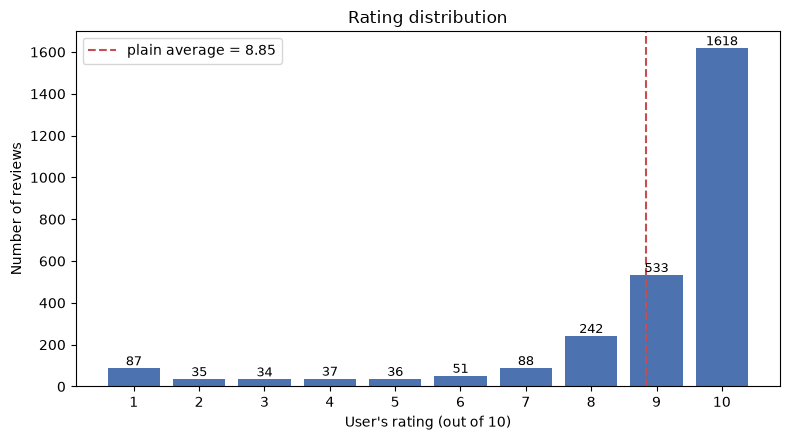

In [55]:
counts = df["rating"].value_counts().reindex(range(1, 11), fill_value=0)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(counts.index, counts.values, color="#4C72B0")
for x, y in zip(counts.index, counts.values):
    ax.text(x, y, str(y), ha="center", va="bottom", fontsize=9)
ax.axvline(df["rating"].mean(), color="#C44E52", linestyle="--",
           label=f"plain average = {df['rating'].mean():.2f}")
ax.set_xticks(range(1, 11))
ax.set_xlabel("User's rating (out of 10)")
ax.set_ylabel("Number of reviews")
ax.set_title("Rating distribution")
ax.legend()
fig.tight_layout()
plt.show()

The plain average is **8.85** with a median of 10. Ratings are extremely polarized: almost 59% of reviews are 10s, while 1–7 together are a thin tail with a small bump at 1.

## Votes by rating

`Total Votes` = readers who answered *"Was this review helpful?"*; `Usefulness Vote` = those who answered *yes*. `helpful_share` = useful votes / total votes for all reviews with that rating.

In [56]:
g = df.groupby("rating")
pd.DataFrame({
    "reviews": g.size(),
    "avg_total_votes": g["total_votes"].mean(),
    "helpful_share": g["useful_votes"].sum() / g["total_votes"].sum(),
}).round(2)

,reviews,avg_total_votes,helpful_share
rating,,,
1,87,67.52,0.35
2,35,29.60,0.36
3,34,22.85,0.37
4,37,13.59,0.38
5,36,14.25,0.35
6,51,8.25,0.35
7,88,2.43,0.40
8,242,3.22,0.38
9,533,2.17,0.58


- **1-star reviews attract the most votes** (≈68 on average) but only **35%** of them are *helpful* – readers actively push back on them.
- **10-star reviews** are judged helpful **71%** of the time.
- So the raw vote count alone is not a quality signal (controversial reviews get many votes); the helpful *share* has to be part of the weight.